In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.abspath('..'))  # on est dans notebooks/

In [16]:
# Ajoute la racine du projet et importe les modules/fonctions utiles
import sys, os
from pathlib import Path


# import pratique - atm_tools
from src.cosmo_lidar.atm_tools import (
    effective_area_and_waist,
    alpha_specific_function,
    optical_depth_emission,
    contribution_effective_area,
    Calcul_T_ant_1_el,
    Calcul_T_ant_2,
    calcul_PWV,
    calcul_z_percentile_wvc,
    vapor_pressure,
    mass_quantile_grid,
    pwv_profile,
)

# import pratique - mc_tools
from src.cosmo_lidar.mc_tools import (
    generate_Pwater_MC,
    generate_Pwater_MC_lognormal,
    monte_carlo_t_ant,
    calcul_snr,
    remove_nans,
    Monte_Carlo_T_ant_mod,
    local_bin_width,
    scale_snr_for_variable_bins,
    predict_SNR_T,
    hybrid_lin_geom,
    Monte_Carlo_T_ant_profile,
)

# import pratique - io
from src.cosmo_lidar.io import (
    fetch_html,
    extract_ut_column_dat_links,
    download_some,
    read_radiosonde_dat,
    read_many_radiosonde,
    save_table,
    load_table,
    load_parquet_columns_as_numpy,
    to_float64,
)

import numpy as np
pi = np.pi
from scipy.interpolate import UnivariateSpline
from scipy.integrate import simpson
from scipy.integrate import trapezoid, cumulative_trapezoid
from matplotlib import pyplot as plt
import pandas as pd

In [3]:
import pycraf
from pycraf import conversions as cnv
from astropy import units as u

We are going to focus on different frequencies to see the  impact of each

f_120 = 120 GHz for Temperature
f_150 = 150 GHz the one I used previously
f_179 = 179 GHz and f_188 = 188 GHz for water vapor 

In [ ]:
f_120 = 120e9 # en Hz
f_150 = 150e9 # en Hz
f_179 = 179e9 # en Hz
f_188 = 188e9 # en Hz


frequencies = np.array([f_120, f_150, f_179, f_188])

theta_b = np.full(len(frequencies), 1*60*pi/(2*180*3600))
elevation = 45
altitudes = np.geomspace(1, 15000, 200) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa

In [ ]:
PWV = 1.22
x = np.linspace(0.01, 10, 100)
PWV_x = x * PWV
T_ant_test = np.zeros_like(x)
i=0
for val in x :
    
    P_water_test = P_water * (val)
    T_ant_test[i] = Calcul_T_ant_1_el(frequencies,theta_b, altitudes, Temperature, Pressure, P_water_test, elevation)
    i=i+1


Calcul en cours...


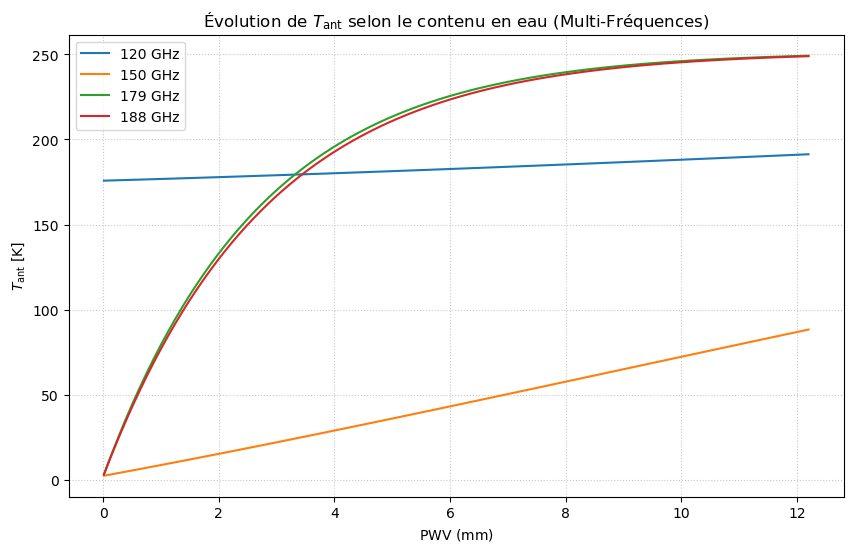

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pycraf.atm
from astropy import units as u

# --- 1. Initialisation des paramètres (Données fournies) ---
pi = np.pi     
f_120 = 120e9 
f_150 = 150e9 
f_179 = 179e9 
f_188 = 188e9 

frequencies = np.array([f_120, f_150, f_179, f_188]) # Array de 4 fréquences

theta_b = np.full(len(frequencies), 1*60*pi/(2*180*3600))
elevation = 45

# Profil atmosphérique de base
altitudes = np.geomspace(1, 15000, 200) + 4999 # m
altitudes_km = (altitudes * u.m).to(u.km)
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value
P_water_base = pycraf.atm.profile_standard(altitudes_km)[3].value # Renommé pour clarté

# --- 2. Boucle de calcul Multi-Fréquences ---

PWV_base = 1.22
x = np.linspace(0.01, 10, 100) # Facteurs d'échelle
PWV_x = x * PWV_base           # Axe X (PWV en mm)

# Initialisation de la matrice de résultats
# Dimensions : [nombre de points PWV, nombre de fréquences]
T_ant_results = np.zeros((len(x), len(frequencies)))

print("Calcul en cours...")

for i, val in enumerate(x):
    
    # Mise à l'échelle de la vapeur d'eau
    P_water_test = P_water_base * val
    
    # Appel de la fonction (qui renvoie un array de taille 4)
    # On stocke le résultat dans la ligne 'i' de la matrice
    T_ant_results[i, :] = Calcul_T_ant_1_el(
        frequencies, 
        theta_b, 
        altitudes, 
        Temperature, 
        Pressure, 
        P_water_test, 
        elevation
    )

# --- 3. Tracé des courbes ---

plt.figure(figsize=(10, 6))

# On boucle sur chaque fréquence pour tracer sa courbe correspondante
for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    # On trace PWV vs la colonne j de la matrice de résultats
    plt.plot(PWV_x, T_ant_results[:, j], label=f'{freq_ghz:.0f} GHz')

plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$T_{\mathrm{ant}}$ [K]")
plt.title(r"Évolution de $T_{\mathrm{ant}}$ selon le contenu en eau (Multi-Fréquences)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

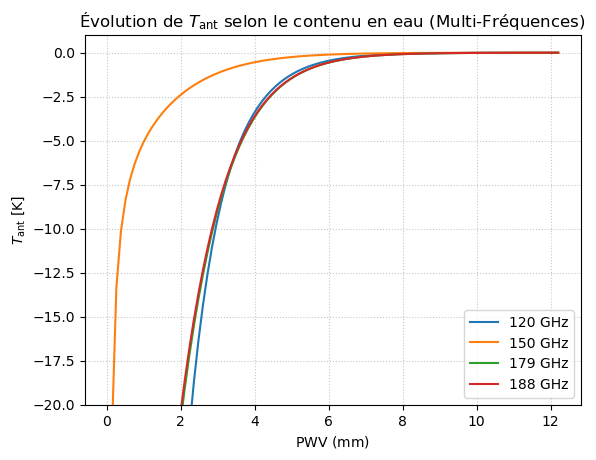

In [12]:
for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    # On trace PWV vs la colonne j de la matrice de résultats
    plt.plot(PWV_x, T_ant_results[:, j]/(1-np.exp(PWV_x)), label=f'{freq_ghz:.0f} GHz')

plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$T_{\mathrm{ant}}$ [K]")
plt.ylim(-20,1)
plt.title(r"Évolution de $T_{\mathrm{ant}}$ selon le contenu en eau (Multi-Fréquences)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Fréquence (GHz)      | k (K)      | c (coeff) 
--------------------------------------------------
120                  | 183.12     | 263.8047  
150                  | 5590.12    | 0.0013    
179                  | 251.83     | 0.3766    
188                  | 252.07     | 0.3625    


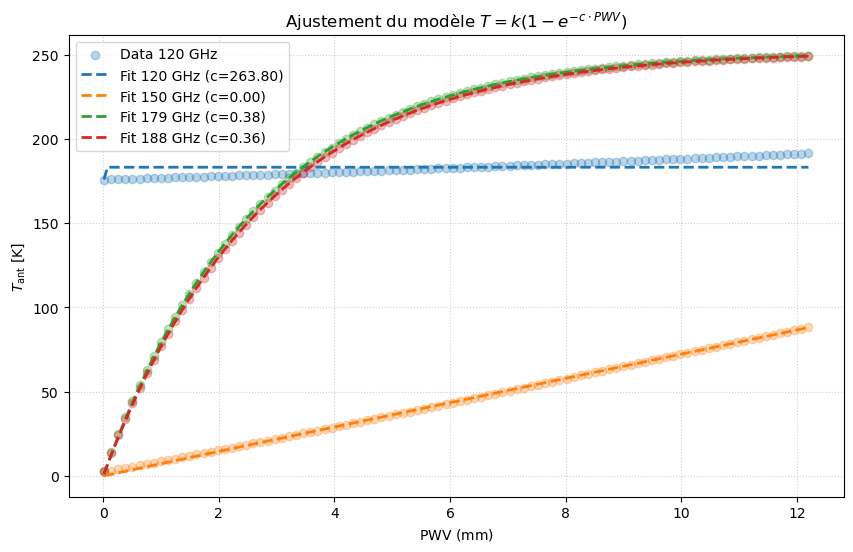

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Définition du modèle (Saturation exponentielle)
def modele_Tant(pwv, k, c):
    # k : Température asymptotique (proche de T_physique moyenne)
    # c : coefficient lié à l'absorption massique de l'eau
    return k * (1 - np.exp(-c * pwv))

# 2. Boucle sur les fréquences
# On prépare des listes pour stocker les résultats si besoin
k_opt_list = []
c_opt_list = []

print(f"{'Fréquence (GHz)':<20} | {'k (K)':<10} | {'c (coeff)':<10}")
print("-" * 50)

plt.figure(figsize=(10, 6))

for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    
    # --- A. Sélection des données pour la fréquence j ---
    # x_data est toujours le même (PWV)
    # y_data change : on prend la colonne j
    y_data_freq = T_ant_results[:, j]
    
    # --- B. Le "Fit" (Ajustement) ---
    # p0=[280, 0.1] sont des valeurs initiales pour aider l'algo
    # k ~ 280 K (température ambiante), c ~ 0.1 (absorption)
    try:
        popt, pcov = curve_fit(modele_Tant, PWV_x, y_data_freq, p0=[280, 0.1])
        
        k_val = popt[0]
        c_val = popt[1]
        
        # Stockage
        k_opt_list.append(k_val)
        c_opt_list.append(c_val)
        
        # Affichage console
        print(f"{freq_ghz:<20.0f} | {k_val:<10.2f} | {c_val:<10.4f}")
        
        # --- C. Tracé pour vérification ---
        # On trace les points bruts
        plt.scatter(PWV_x, y_data_freq, alpha=0.3, label=f'Data {freq_ghz:.0f} GHz' if j==0 else "")
        
        # On trace la courbe modèle
        # On crée une ligne lisse pour le modèle
        x_smooth = np.linspace(PWV_x.min(), PWV_x.max(), 200)
        y_model = modele_Tant(x_smooth, k_val, c_val)
        
        #color = plt.gca().lines[-1].get_color() # Récupère la couleur du scatter précédent (astuce matplotlib)
        # Note: scatter ne met pas à jour lines, donc on force la couleur via le cycle ou on laisse auto
        plt.plot(x_smooth, y_model, '--', linewidth=2, label=f'Fit {freq_ghz:.0f} GHz (c={c_val:.2f})')
        
    except RuntimeError:
        print(f"Erreur de fit pour {freq_ghz} GHz")

plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$T_{\mathrm{ant}}$ [K]")
plt.title(r"Ajustement du modèle $T = k(1 - e^{-c \cdot PWV})$")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Conversion en arrays numpy pour usage ultérieur
k_opts = np.array(k_opt_list)
c_opts = np.array(c_opt_list)

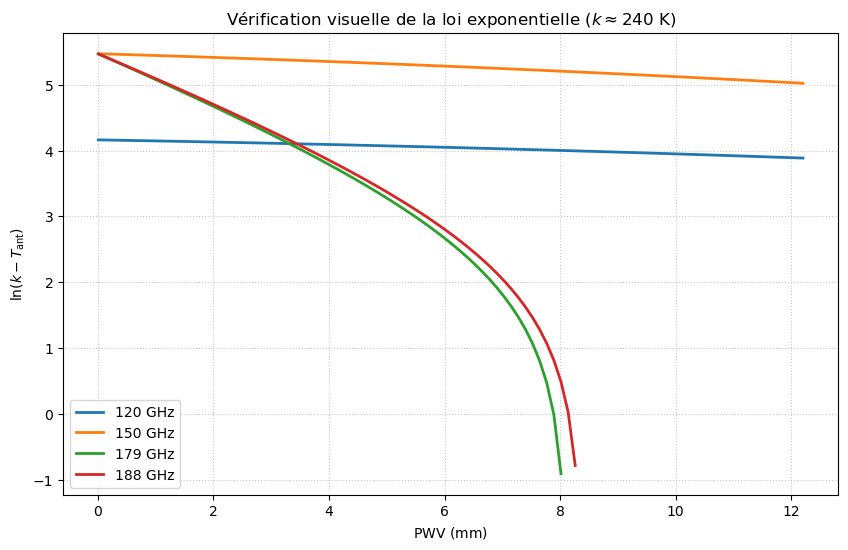

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Choix de la température asymptotique k ---
# Dans l'idéal, c'est la température physique moyenne du milieu.
# On prend ici la température au sol (la première valeur du profil), 
# car T_ant ne peut physiquement pas dépasser cette valeur (corps noir).
k_physique = 240 # C'est un scalaire (environ 288 K pour le profil standard)

plt.figure(figsize=(10, 6))

# --- 2. Boucle sur les fréquences ---
for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    
    # Récupération des données T_ant pour cette fréquence
    y_data = T_ant_results[:, j]
    
    # --- Transformation des données ---
    # Formule : Y = ln( k - T_ant )
    # On ajoute une sécurité : on ne garde que les points où T_ant < k
    mask_valid = y_data < k_physique
    
    if np.sum(mask_valid) > 0:
        # On filtre les données
        pwv_valid = PWV_x[mask_valid]
        y_valid = y_data[mask_valid]
        
        # Calcul du logarithme
        # Le terme (k - T) représente le "manque à gagner" pour atteindre la saturation
        log_term = np.log(k_physique - y_valid)
        
        # --- Tracé ---
        plt.plot(pwv_valid, log_term, linewidth=2, label=f'{freq_ghz:.0f} GHz')
        
        # (Optionnel) Calcul de la pente locale pour vérifier c
        # slope = (log_term[-1] - log_term[0]) / (pwv_valid[-1] - pwv_valid[0])
        # print(f"Pente estimée (-c) pour {freq_ghz:.0f} GHz : {slope:.3f}")

# --- 3. Mise en forme ---
plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$\ln(k - T_{\mathrm{ant}})$")
plt.title(r"Vérification visuelle de la loi exponentielle ($k \approx " + f"{k_physique:.0f}$ K)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Si c'est une droite, le modèle est valide.
# La pente de la droite correspond à -c.
plt.show()

Test de l'impact de la hauteur max

In [ ]:
import numpy as np
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
import matplotlib.pyplot as plt

# --- 1. Paramètres initiaux ---
pi = np.pi     

# Définition des multiples fréquences
f_120 = 120e9
f_150 = 150e9
f_179 = 179e9
f_188 = 188e9
frequencies = np.array([f_120, f_150, f_179, f_188]) # Hz

# Theta_b pour chaque fréquence (ici supposé constant à 1 arcmin, 
# mais vous pourriez le faire varier en fct de lambda/D si besoin)
theta_b_all = np.full(len(frequencies), 1*60*pi/(2*180*3600))

elevation = 90
elev = 45 # en deg
N = 500
N_MC = 200

# --- 2. Profils Atmosphériques (Commun à toutes les fréquences) ---
altitudes = np.geomspace(1, 30000, 1000) # m
altitudes = altitudes + 4999 # m

altitudes_km = altitudes * u.m       
altitudes_km = altitudes_km.to(u.km) 

# Récupération des données Pycraf
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value # K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value # hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value # g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value # hPa

# Calcul WVMR
epsilon = 0.622 
WVMR = epsilon * P_water / (Pressure - P_water) # kg/kg
WVMR = WVMR * 1000 # g/kg

# --- 3. Calcul du SNR (Commun car dépend du Lidar, pas du radiomètre) ---
# Valeurs de Patrick
A = 106533.049
c = 1.470303e-05

SNR_no_scale = calcul_snr(A, c, WVMR, altitudes, Pressure, Temperature, elev)
# On prend l'index [0] si scale_snr renvoie un tuple ou array
SNR = scale_snr_for_variable_bins(altitudes, SNR_no_scale, elev=90, dz_ref=30.0)[0]


# --- 4. Boucle de Simulation par Fréquence ---

# Dictionnaire pour stocker les résultats : {frequence: (sigma_prof, T_mean_prof, T_dry_prof)}
results_dict = {}

print(f"Lancement des simulations Monte Carlo pour {len(frequencies)} fréquences...")

for i, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    print(f"Processing {freq_ghz:.0f} GHz...")
    
    # On prépare les arguments scalaires ou tableaux unitaires pour la fonction
    f_input = np.array([freq])
    theta_b_input = np.array([theta_b_all[i]])
    
    # Appel de la fonction MC
    # Renvoie : sigma_prof, T_mean_prof, T_dry_prof
    simu_freq = Monte_Carlo_T_ant_profile(
        f_input, 
        theta_b_input, 
        N, 
        elev, 
        generate_Pwater_MC_lognormal, 
        N_MC, 
        WVMR, 
        SNR, 
        Temperature, 
        Pressure, 
        altitudes
    )
    
    # Stockage
    results_dict[freq] = simu_freq


# --- 5. Exemple de visualisation (Comparaison des fréquences) ---
plt.figure(figsize=(12, 6))

for freq in frequencies:
    freq_ghz = freq / 1e9
    # Récupération des résultats
    sigma_prof, T_mean_prof, T_dry_prof = results_dict[freq]
    
    # On trace T_mean (Total)
    plt.plot(altitudes/1000, T_mean_prof, label=f'{freq_ghz:.0f} GHz')
    
    # Optionnel : afficher sigma en pointillé (x10 pour visibilité)
    # plt.plot(altitudes/1000, sigma_prof*10, '--', alpha=0.5)

plt.xlabel("Altitude d'intégration $z_{max}$ [km]")
plt.ylabel("Température d'antenne cumulée [K]")
plt.title("Profils verticaux $T_{ant}$ pour différentes fréquences")
plt.legend()
plt.grid(True)
plt.show()

Lancement des simulations Monte Carlo pour 4 fréquences...
Processing 120 GHz...
Processing 150 GHz...
Processing 179 GHz...


Test de l'impact de PWV sur sigma_T

In [ ]:
import numpy as np
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
from scipy.integrate import trapezoid  # Pour l'intégration numérique
import matplotlib.pyplot as plt


# =============================================================================
# 2. INITIALISATION ET MAILLAGE HAUTE RÉSOLUTION (z_1)
# =============================================================================

# Paramètres généraux
pi = np.pi     

elev = 45
N_MC = 70
epsilon = 0.622
R_water = 461.5 # J/kg/K

# -- 2a. Création de la grille fine linéaire (z_1) --
# On prend large (ex: 2000 points) pour avoir une bonne précision sur z_moy et z_break
altitudes_hr = np.linspace(5000, 15000, 2000) # m
z_1 = altitudes_hr
z_1_km = (z_1 * u.m).to(u.km)

# -- 2b. Récupération des profils Pycraf sur la grille fine --
profile = pycraf.atm.profile_standard(z_1_km)
T_1 = profile[0].value        # K
P_1 = profile[1].value        # hPa
rho_water_1_base = profile[2].value # g/m^3 (Profil standard de base)
P_water_1_base = profile[3].value   # hPa (Profil standard de base)

# =============================================================================
# 3. CRÉATION DE LA GRILLE RÉDUITE OPTIMISÉE (zg)
# =============================================================================

N_Z = 200
N_lin = 4 * N_Z // 5
N_geom = N_Z - N_lin
gamma = 2
Z_FLOOR = 5000

# Calcul du z_break sur le profil standard (la forme ne change pas avec le scaling)
z_break = calcul_z_percentile_wvc(z_1, rho_water_1_base, 90)
print(f"Altitude de coupure (90% eau) : {z_break:.1f} m")

zmin = max(float(np.nanmin(z_1)), Z_FLOOR)
zmax = float(np.nanmax(z_1))

# Génération du maillage réduit
zg = hybrid_lin_geom(zmin, z_break, zmax, N_lin=N_lin, N_geom=N_geom, gamma=gamma)

# =============================================================================
# 4. BOUCLE DE CALCUL AVEC SCALING PWV
# =============================================================================

# Facteurs d'échelle PWV
x_scale = np.linspace(0.01, 10, 20)

# Tableaux pour stocker les résultats
sigma_T_results = np.zeros_like(x_scale)
T_ant_results = np.zeros_like(x_scale)
z_moy_results = np.zeros_like(x_scale)
std_vert_results = np.zeros_like(x_scale)
PWV_results = np.zeros_like(x_scale) # Pour vérification

print(f"Lancement de la simulation pour {len(x_scale)} points...")

for i, val in enumerate(x_scale):
    
    # --- A. Mise à l'échelle sur la grille HAUTE RÉSOLUTION (z_1) ---
    # On travaille sur z_1 pour calculer les intégrales (z_moy, std) avec précision
    
    P_water_1_scaled = P_water_1_base * val
    
    # Recalcul de rho_water sur z_1 (Loi des gaz parfaits pour la vapeur d'eau)
    # rho = P / (R * T). Attention aux unités : P en Pascal pour formule SI
    # P_water_1_scaled est en hPa -> * 100 pour Pa
    # T_1 en K
    # R_water = 461.5 J/kg/K
    # Resultat en kg/m3 -> * 1000 pour g/m3
    rho_water_1_scaled = (P_water_1_scaled * 100) / (R_water * T_1) * 1000 # g/m^3
    
    # --- B. Calcul des statistiques verticales sur z_1 ---
    
    # Calcul du PWV total (intégrale de rho selon z) en g/m^2 ou mm
    current_PWV = trapezoid(rho_water_1_scaled, z_1)
    
    # Altitude moyenne (z_moy)
    # Intégrale (rho * z) / PWV
    z_moy = trapezoid(rho_water_1_scaled * z_1, z_1) / current_PWV
    
    # Variance et Ecart-type vertical
    var_vert = trapezoid(rho_water_1_scaled * (z_1 - z_moy)**2, z_1) / current_PWV
    std_vert = np.sqrt(var_vert)
    
    # Stockage des stats
    z_moy_results[i] = z_moy
    std_vert_results[i] = std_vert
    PWV_results[i] = current_PWV / 1000 # Conversion souvent utile (kg/m^2) si rho en g
    
    # --- C. Interpolation vers la grille RÉDUITE (zg) pour Monte Carlo ---
    
    # Interpolation des champs scalés depuis z_1 vers zg
    T_g = np.interp(zg, z_1, T_1)
    P_g = np.interp(zg, z_1, P_1)
    P_water_g = np.interp(zg, z_1, P_water_1_scaled)
    
    # Recalcul du WVMR sur la grille réduite
    # WVMR = epsilon * P_w / (P_dry) = epsilon * P_w / (P_tot - P_w)
    denom = P_g - P_water_g
    denom[denom <= 0] = 1e-6 # Sécurité numérique
    
    WVMR_g = epsilon * P_water_g / denom * 1000 # g/kg
    
    # --- D. Appel de la fonction de prédiction ---
    
    # On passe les vecteurs réduits (_g)
    sig, temp = predict_SNR_T(
        frequency=frequencies,
        theta_b=theta_b,
        z=zg,           # Grille réduite
        WVMR=WVMR_g,    # Profil interpolé
        elev=elev,
        T=T_g,
        P=P_g,
        N_MC=N_MC
    )
    
    # Moyenne si la fonction retourne un array
    sigma_T_results[i] = sig
    T_ant_results[i] = temp